# Classifying Penguins with Keras Day 2

In [2]:
import sys
!{sys.executable} -m pip install optuna

  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 12.1 MB/s  0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ --------------------------------- 1/6 [greenlet]
   ------ -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [2]:
!pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\2003n\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [4]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\2003n\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
# drop Nan rows
penguins.dropna(inplace=True)

In [6]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [7]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [15]:
tf.keras.utils.set_random_seed(42)


In [16]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [17]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [18]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.0142 - loss: 1.3868 - val_accuracy: 0.0185 - val_loss: 1.3452
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0236 - loss: 1.3691 - val_accuracy: 0.0370 - val_loss: 1.3277
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0377 - loss: 1.3517 - val_accuracy: 0.0556 - val_loss: 1.3104
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0566 - loss: 1.3348 - val_accuracy: 0.0741 - val_loss: 1.2935
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0660 - loss: 1.3182 - val_accuracy: 0.1111 - val_loss: 1.2768
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0708 - loss: 1.3019 - val_accuracy: 0.1481 - val_loss: 1.2605
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0802 - loss: 1.2859 - val_accuracy: 0.1667 - val_loss: 1.2445
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1085 - loss: 1.2703 - val_accuracy: 0.2037 - val_loss: 1.2290

### Evaluating on the test data

In [19]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

 Test Set Evaluation:
Test Accuracy: 0.2687
Test Precision: 0.1172
Test Recall: 0.2687
Test F1 Score: 0.1632
Test ROC AUC Score: 0.4170


### Evaluating model training using loss and accuracy

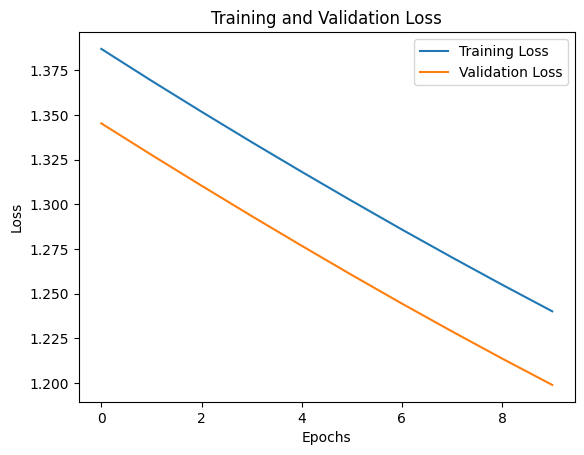

In [20]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

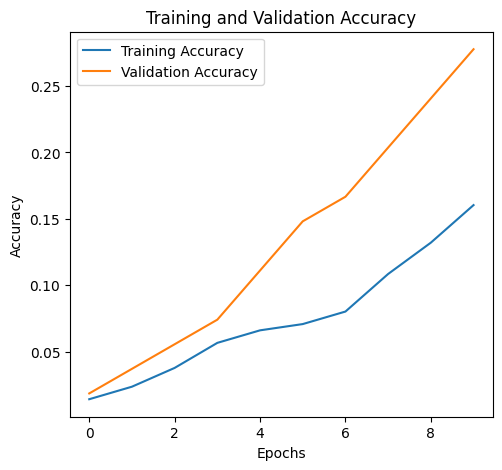

In [21]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

Run 1
Final Training Accuracy: 0.5189
Final Validation Accuracy: 0.5000
Final Training Loss: 0.9034
Final Validation Loss: 0.8653



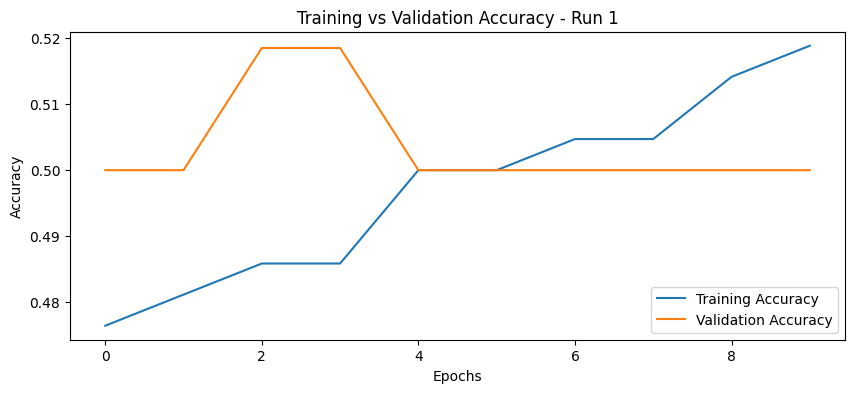

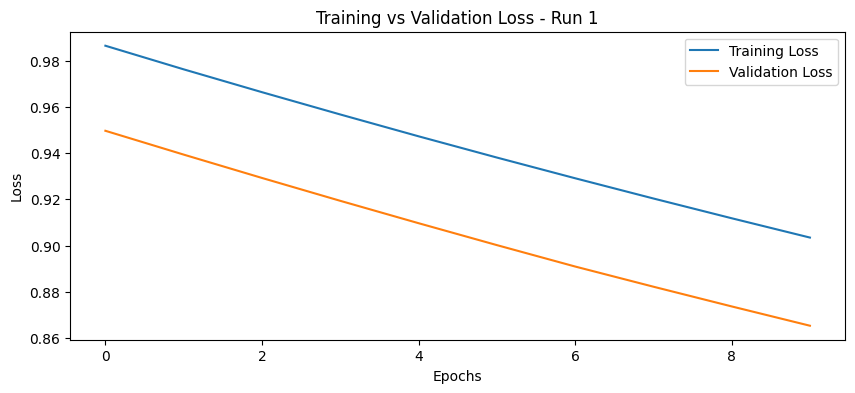

Run 2
Final Training Accuracy: 0.4245
Final Validation Accuracy: 0.4259
Final Training Loss: 0.9621
Final Validation Loss: 0.9073



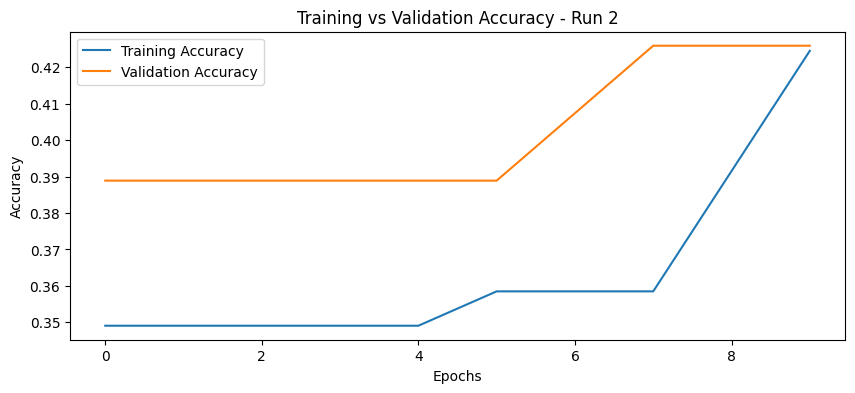

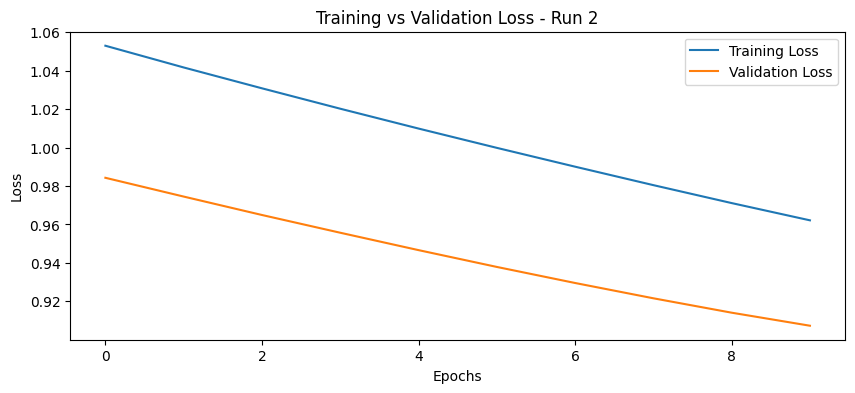

Run 3
Final Training Accuracy: 0.5991
Final Validation Accuracy: 0.5926
Final Training Loss: 1.0414
Final Validation Loss: 1.0315



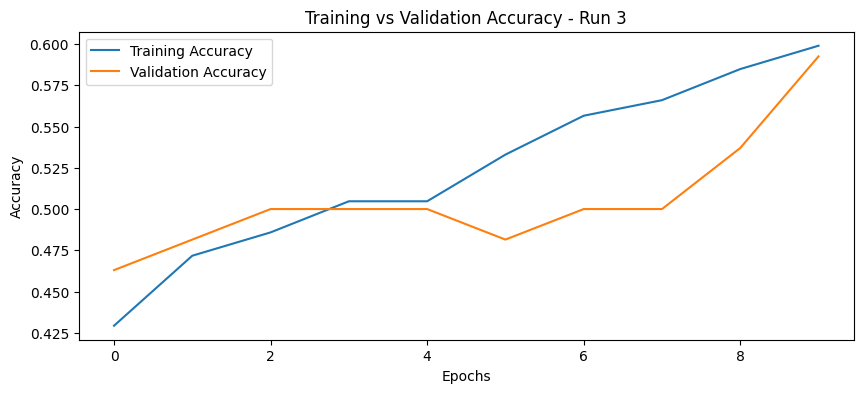

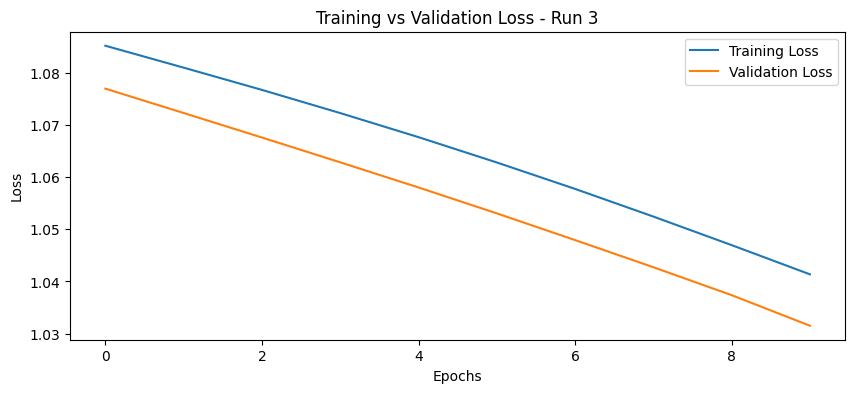

In [23]:

for run in range(1, 4):

    # Define model
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(7, activation='relu')(inputs)
    x = layers.Dense(5, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile model
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=128,
        epochs=10,
        validation_split=0.2,
        verbose=0
    )

    # Print final results
    print(f"Run {run}")
    print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print()

    # Plot accuracy curves
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Validation Accuracy - Run {run}')
    plt.legend()
    plt.show()

    # Plot loss curves
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss - Run {run}')
    plt.legend()
    plt.show()

Run 1 performed the best, with the highest validation accuracy of 0.6111. Run 2 performed much worse, with a validation accuracy of 0.3519. Run 3 performed the worst, with a validation accuracy of only 0.1667. This happened because the model was trained without setting a random seed. Each run starts with different random initial weights, uses different random mini-batches, and may use a different validation split. Because neural networks are sensitive to these random starting conditions, the model can learn differently each time.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

Setting the random seed made the results more reproducible, but the training and validation curves were still not exactly the same across the three runs. The seed controls the random process, but since the model is being recreated multiple times inside the loop, each run can still use a different random initialization from the seeded random sequence. This causes the models to learn slightly differently. Compared to the no-seed version, the results are more controlled, but the curves are still different because neural network training depends on random weight initialization, mini-batch updates, and validation splitting.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

Config 1: Small funnel 7-5
Architecture: [7, 5]
Test Accuracy: 0.3134
Test Loss: 1.2665



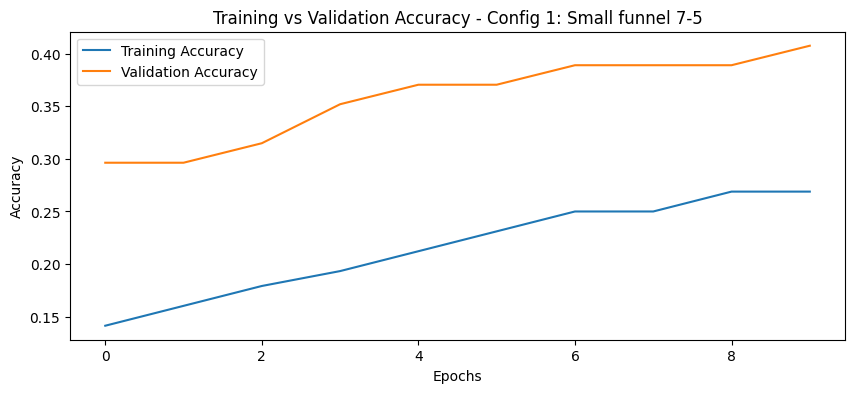

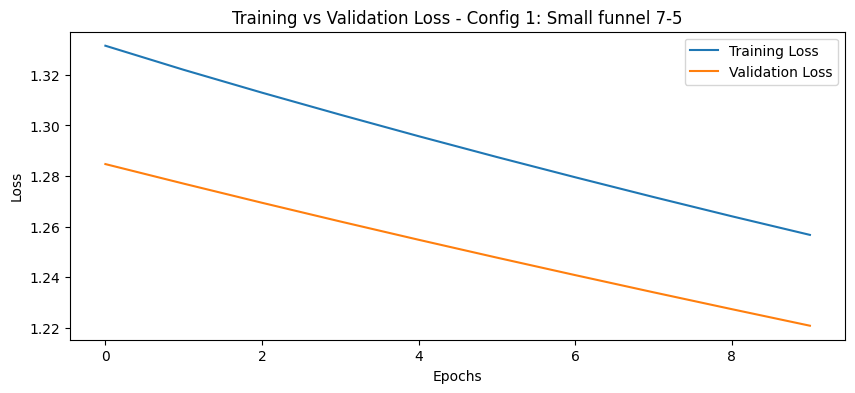

Config 2: Larger funnel 16-8
Architecture: [16, 8]
Test Accuracy: 0.3881
Test Loss: 1.0744



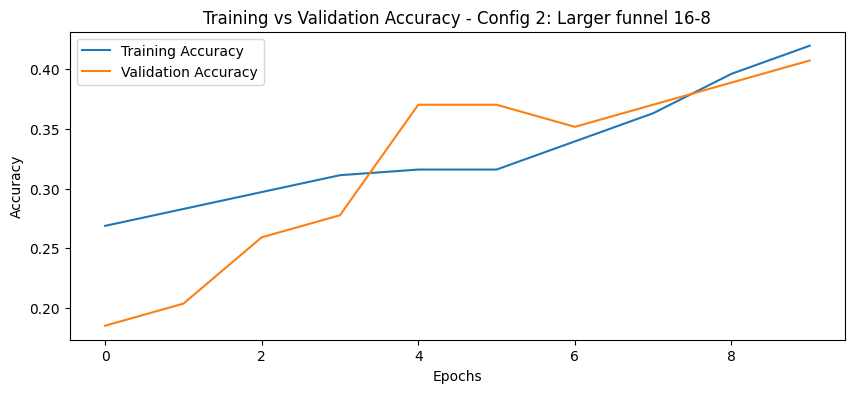

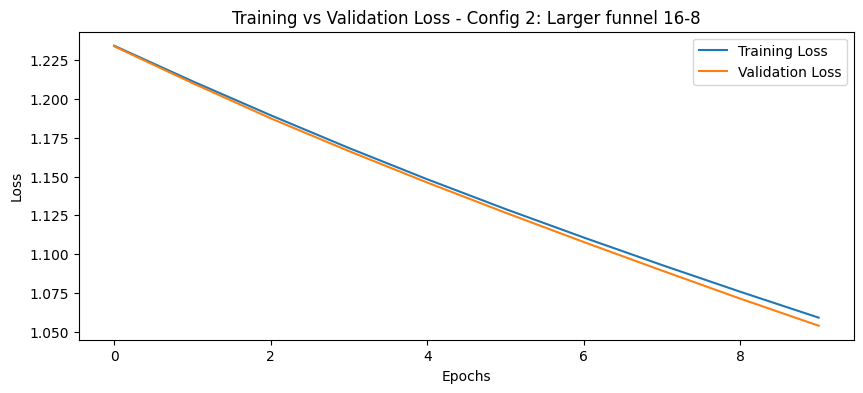

Config 3: Flat 12-12
Architecture: [12, 12]
Test Accuracy: 0.6119
Test Loss: 1.0174



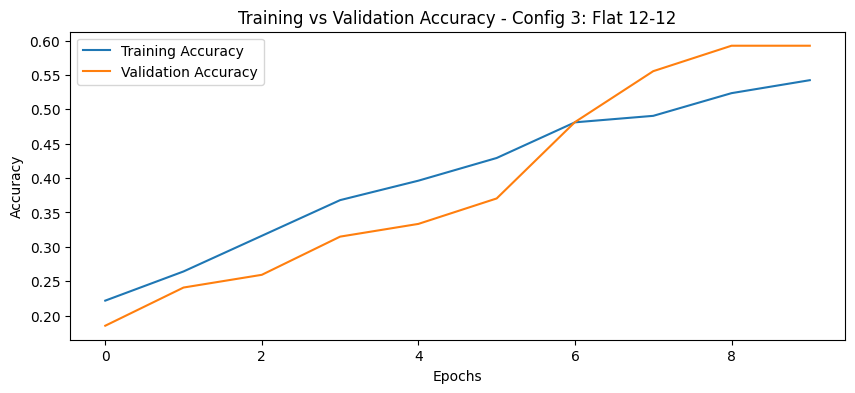

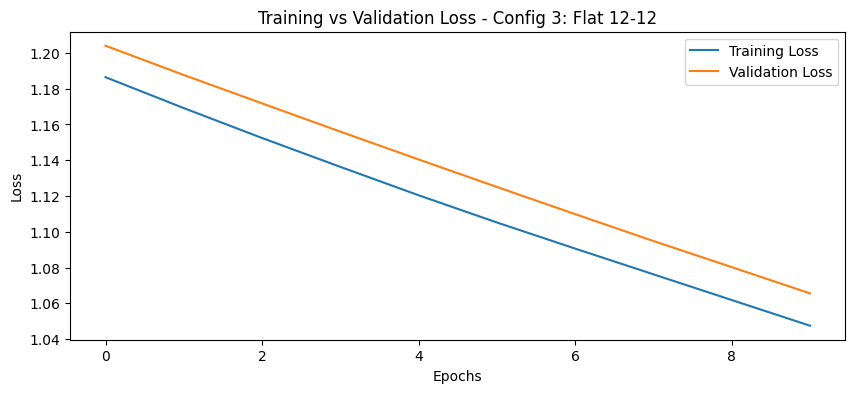

In [24]:
# Three hidden layer configurations to test
configs = {
    "Config 1: Small funnel 7-5": [7, 5],
    "Config 2: Larger funnel 16-8": [16, 8],
    "Config 3: Flat 12-12": [12, 12]
}

results = []

for config_name, hidden_layers in configs.items():

    # Define model
    inputs = keras.Input(shape=(6,))
    x = inputs

    for neurons in hidden_layers:
        x = layers.Dense(neurons, activation='relu')(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile model
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=128,
        epochs=10,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )

    # Save results
    results.append({
        "Configuration": config_name,
        "Architecture": hidden_layers,
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss
    })

    print(config_name)
    print(f"Architecture: {hidden_layers}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print()

    # Plot accuracy curves
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Validation Accuracy - {config_name}')
    plt.legend()
    plt.show()

    # Plot loss curves
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss - {config_name}')
    plt.legend()
    plt.show()

Configuration 1 used two hidden layers with 7 neurons in the first layer and 5 neurons in the second layer. This model had the weakest performance, with a test accuracy of 0.3134 and a test loss of 1.2665. The training and validation accuracy increased slightly, but both stayed fairly low. This suggests that the model may have been too small to learn the patterns in the data well.

Configuration 2 used a larger funnel structure with 16 neurons in the first hidden layer and 8 neurons in the second hidden layer. This model performed better than Configuration 1, with a test accuracy of 0.3881 and a test loss of 1.0744. The accuracy curves improved over time, and the loss curves steadily decreased, showing that the model was learning. However, the final accuracy was still not very high, so this architecture was better but still limited.

Configuration 3 used a flat structure with 12 neurons in both hidden layers. This model performed the best, with a test accuracy of 0.6119 and a test loss of 1.0174. The training and validation accuracy both increased steadily, and the validation accuracy reached the highest level out of all three models. This suggests that the flat structure gave the model enough capacity to learn without reducing the neuron count too quickly.

Overall, Configuration 3 worked best because it had the highest test accuracy and lowest test loss. The flat [12, 12] structure seemed to learn the data better than the funnel-shaped models.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

Epochs: 10
Test Accuracy: 0.2239
Test Loss: 1.1872
Final Training Accuracy: 0.2783
Final Validation Accuracy: 0.2407
Final Training Loss: 1.2362
Final Validation Loss: 1.1584



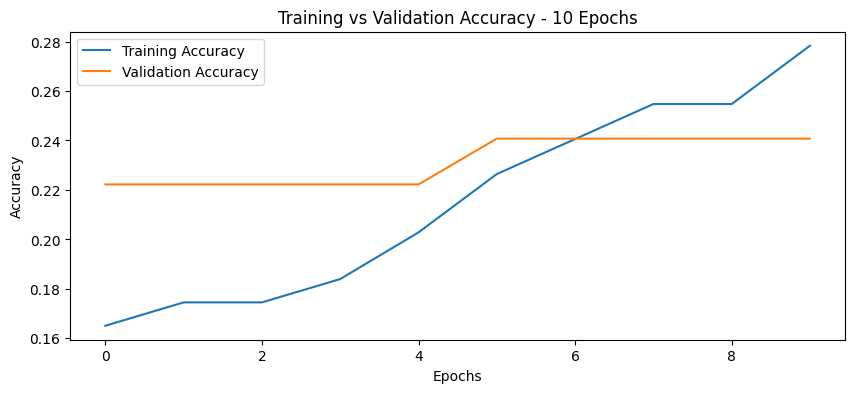

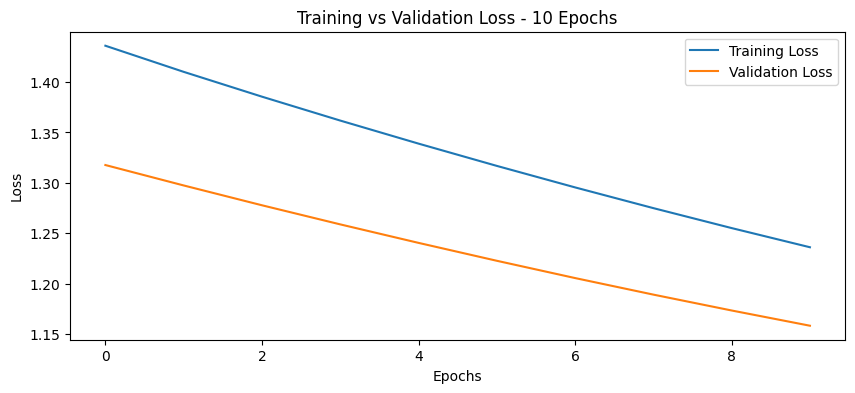

Epochs: 25
Test Accuracy: 0.8060
Test Loss: 0.6003
Final Training Accuracy: 0.8302
Final Validation Accuracy: 0.8519
Final Training Loss: 0.5832
Final Validation Loss: 0.5687



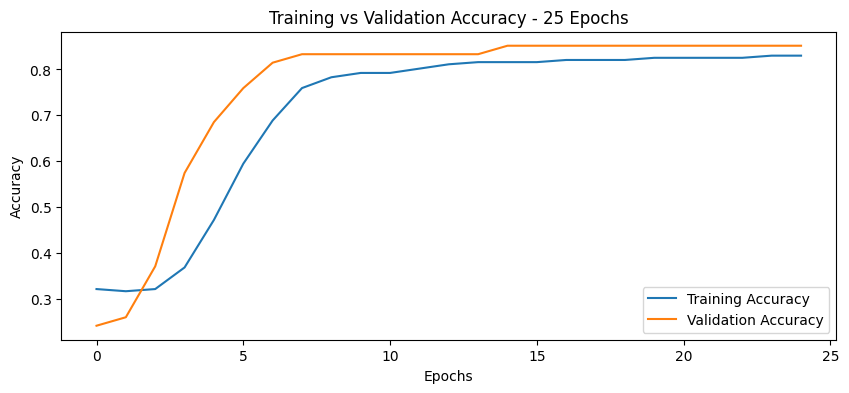

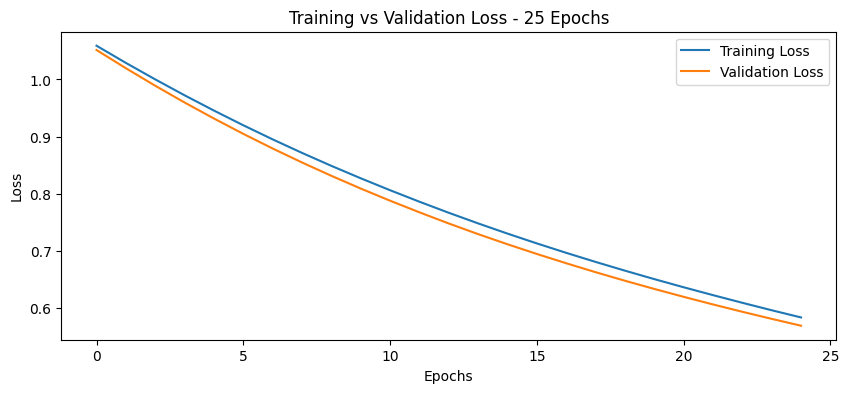

Epochs: 50
Test Accuracy: 0.9552
Test Loss: 0.5759
Final Training Accuracy: 0.9575
Final Validation Accuracy: 0.9444
Final Training Loss: 0.5775
Final Validation Loss: 0.5592



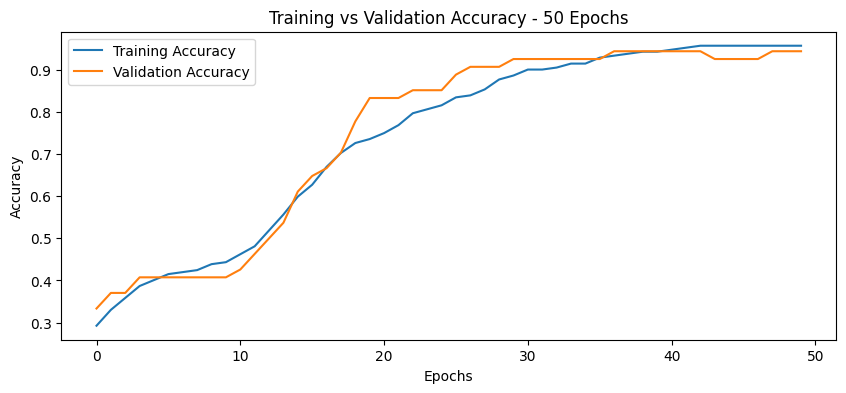

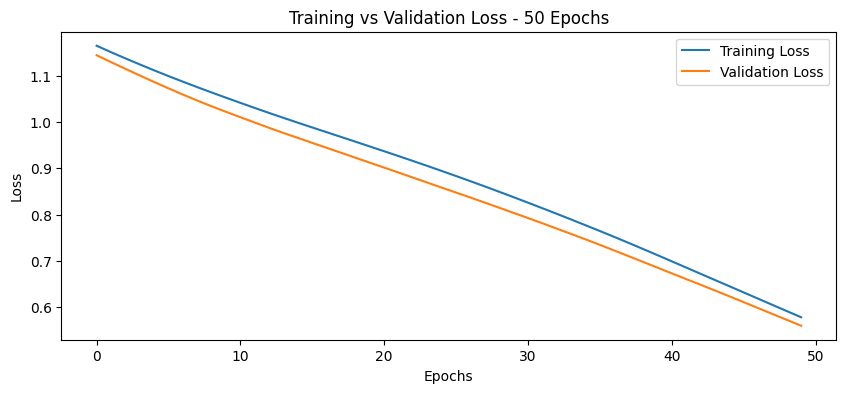

Epochs: 100
Test Accuracy: 0.9701
Test Loss: 0.1500
Final Training Accuracy: 0.9764
Final Validation Accuracy: 0.9815
Final Training Loss: 0.1438
Final Validation Loss: 0.1629



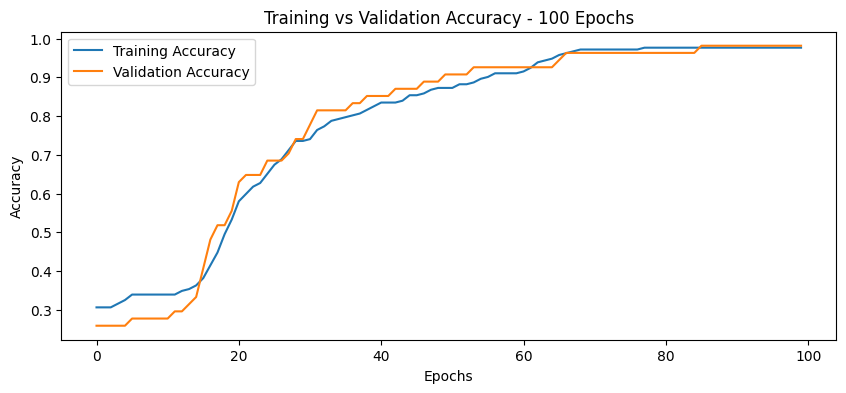

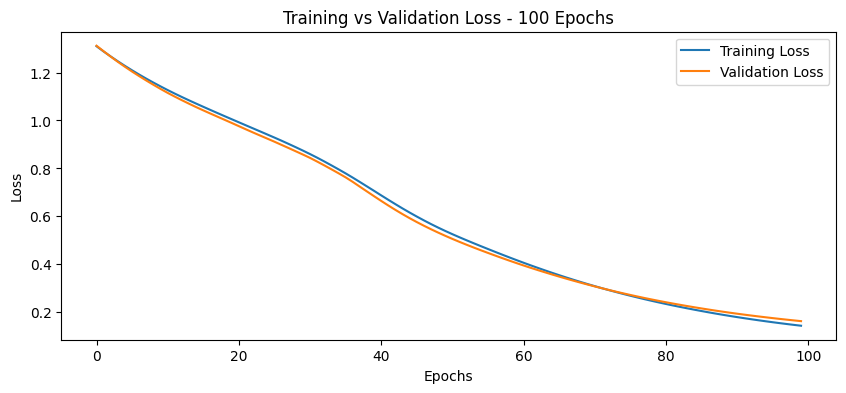

,Epochs,Test Accuracy,Test Loss,Final Training Accuracy,Final Validation Accuracy,Final Training Loss,Final Validation Loss
0,10,0.223881,1.187239,0.278302,0.240741,1.236210,1.158425
1,25,0.805970,0.600299,0.830189,0.851852,0.583199,0.568721
2,50,0.955224,0.575897,0.957547,0.944444,0.577460,0.559151
3,100,0.970149,0.150000,0.976415,0.981481,0.143751,0.162887


In [25]:
# Different epoch configurations to test
epoch_configs = [10, 25, 50, 100]

epoch_results = []

for num_epochs in epoch_configs:

    # Define model using best hidden layer configuration from previous section
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(12, activation='relu')(inputs)
    x = layers.Dense(12, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile model
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=128,
        epochs=num_epochs,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )

    # Save results
    epoch_results.append({
        "Epochs": num_epochs,
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss,
        "Final Training Accuracy": history.history['accuracy'][-1],
        "Final Validation Accuracy": history.history['val_accuracy'][-1],
        "Final Training Loss": history.history['loss'][-1],
        "Final Validation Loss": history.history['val_loss'][-1]
    })

    print(f"Epochs: {num_epochs}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print()

    # Plot accuracy curves
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Validation Accuracy - {num_epochs} Epochs')
    plt.legend()
    plt.show()

    # Plot loss curves
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss - {num_epochs} Epochs')
    plt.legend()
    plt.show()

# Display results in a table
epoch_results_df = pd.DataFrame(epoch_results)
epoch_results_df

With 10 epochs, the model did not train long enough. The test accuracy was only 0.2239, and the test loss was 1.1872. The training accuracy increased slightly, but the validation accuracy stayed low and mostly flat around 0.24. This suggests the model was underfitting because it had not gone through enough training cycles to learn the patterns in the data.

With 25 epochs, the model improved a lot. The test accuracy increased to 0.8060, and the test loss dropped to 0.6003. Both the training and validation accuracy increased quickly, then started to level off near the end. The loss curves also steadily decreased. This shows that 25 epochs gave the model enough time to learn much better than 10 epochs.

With 50 epochs, the model performed even better, with a test accuracy of 0.9552 and a test loss of 0.5759. The training and validation accuracy curves increased steadily and stayed close together, which suggests the model was learning well without major overfitting. The validation accuracy reached about 0.9444, showing strong performance.

With 100 epochs, the model had the best overall performance. The test accuracy was 0.9701, and the test loss was much lower at 0.1500. The training and validation accuracy both became very high, with final validation accuracy at 0.9815. The loss curves also decreased smoothly. This shows that the model continued improving with more epochs.

50 epochs was the minimum reliable choice, even though 100 epochs performed slightly better with a test accuracy of 0.9701.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [26]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.2453 - loss: 1.3697 - val_accuracy: 0.1667 - val_loss: 1.3243
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2406 - loss: 1.3434 - val_accuracy: 0.1667 - val_loss: 1.3080
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2406 - loss: 1.3250 - val_accuracy: 0.1667 - val_loss: 1.2928
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2406 - loss: 1.3025 - val_accuracy: 0.1667 - val_loss: 1.2790
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2406 - loss: 1.2848 - val_accuracy: 0.1667 - val_loss: 1.2664
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2877 - loss: 1.2702 - val_accuracy: 0.1667 - val_loss: 1.2544
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2500 - loss: 1.2682 - val_accuracy: 0.1667 - val_loss: 1.2429
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3160 - loss: 1.2462 - val_accuracy: 0.1852 - val_loss:

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [38]:
def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    inputs = keras.Input(shape=(6,))
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)
        x = layers.Dense(units, activation="relu")(x)

    outputs = layers.Dense(3, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,
        validation_split=0.2,
        verbose=1,
        callbacks=[early_stop],
    )

    return min(history.history["val_loss"])

In [39]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [40]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3726 - loss: 1.0919 - val_accuracy: 0.4444 - val_loss: 1.0737
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5236 - loss: 1.0529 - val_accuracy: 0.5185 - val_loss: 1.0368
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5377 - loss: 1.0152 - val_accuracy: 0.5370 - val_loss: 0.9976
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5472 - loss: 0.9679 - val_accuracy: 0.5556 - val_loss: 0.9458
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5991 - loss: 0.9091 - val_accuracy: 0.7593 - val_loss: 0.8829
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7264 - loss: 0.8409 - val_accuracy: 0.7593 - val_loss: 0.8156
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7264 - loss: 0.7699 - val_accuracy: 0.7593 - val_loss: 0.7502
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7217 - loss: 0.7025 - val_accuracy: 0.7407 - val_loss: 0.6910
Ep